In [21]:
import lightning as L
import numpy as np
import time
import pickle
import torch
import torch.nn.functional as F
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from torchdyn.core import NeuralODE

from scRatio.datamodules import ArrayDataset
from scRatio.models import *

In [2]:
def prepare_dataset(n, N, cond_dim, locs):
    C = np.random.randint(low=0, high=cond_dim, size=(N))
    X = np.concatenate([np.random.normal(loc=locs[c], scale=1, size=(1, n)) for c in C])

    X_train, X_val_test, C_train, C_val_test = train_test_split(X, C, test_size=20_000)
    X_val, X_test, C_val, C_test = train_test_split(X_val_test, C_val_test, test_size=10_000)

    X_train = torch.tensor(X_train).to("cuda").float()
    C_train = F.one_hot(torch.tensor(C_train).long(), num_classes=cond_dim).to("cuda").float()

    X_val = torch.tensor(X_val).to("cuda").float()
    C_val = F.one_hot(torch.tensor(C_val).long(), num_classes=cond_dim).to("cuda").float()

    X_test = torch.tensor(X_test).to("cuda").float()
    C_test = F.one_hot(torch.tensor(C_test).long(), num_classes=cond_dim).to("cuda").float()
    return X_train, X_val, X_test, C_train, C_val, C_test

def build_train_loader(x_train, c_train, batch_size):
    dataset = ArrayDataset(x_train, c_train)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

def rl_evaluate_model(model, data_samples, cond, cond_dim, condition, control, locs):
    device = data_samples.device
    model = model.to(device)

    log_condition_true = -0.5 * ((data_samples.cpu().numpy() - np.array(locs[np.argmax(condition)])) ** 2).sum(axis=1) - 0.5 * data_samples.shape[1] * np.log(2 * np.pi)
    log_control_true = -0.5 * ((data_samples.cpu().numpy() - np.array(locs[np.argmax(control)])) ** 2).sum(axis=1) - 0.5 * data_samples.shape[1] * np.log(2 * np.pi)
    log_ratio_true = log_condition_true - log_control_true

    condition = torch.from_numpy(condition).float().to(device).expand(data_samples.shape[0], cond_dim)
    control = torch.from_numpy(control).float().to(device).expand(data_samples.shape[0], cond_dim)
    
    log_ratio_hat = model.estimate_log_density_ratio(data_samples, condition, control, cond, n_steps=100)
    
    return log_ratio_true, log_ratio_hat

def get_params(num_dims):
    if num_dims == 2:
        time_feature_dim = 32
        latent_dim = 32
        cond_latent_dim = 64
    elif num_dims == 5:
        time_feature_dim = 1
        latent_dim = 256
        cond_latent_dim = 64
    elif num_dims == 10:
        time_feature_dim = 32
        latent_dim = 32
        cond_latent_dim = 32
    elif num_dims == 20:
        time_feature_dim = 1
        latent_dim = 64
        cond_latent_dim = 128
    elif num_dims == 30:
        time_feature_dim = 1
        latent_dim = 32
        cond_latent_dim = 128
    elif num_dims == 50:
        time_feature_dim = 32
        latent_dim = 256
        cond_latent_dim = 32
    else:
        raise ValueError("Unknown num_dims value")
        
    return latent_dim, time_feature_dim, cond_latent_dim

In [62]:
def exact_div_fn(u):
    J = torch.func.jacrev(u)
    return lambda x, *args: torch.trace(J(x))

def div_fn_hutch_trace(u):
    def div_fn(x, eps):
        _, vjpfunc = torch.func.vjp(u, x)
        return (vjpfunc(eps)[0] * eps).sum()

    return div_fn

def get_div_and_eps(likelihood_estimator):
    if likelihood_estimator == "exact":
        return exact_div_fn, None
    if likelihood_estimator == "hutch_gaussian":
        return div_fn_hutch_trace, torch.randn_like
    if likelihood_estimator == "hutch_rademacher":

        def eps_fn(x):
            return torch.randint_like(x, low=0, high=2).float() * 2 - 1.0

        return div_fn_hutch_trace, eps_fn
    
    raise NotImplementedError(
        f"likelihood estimator {likelihood_estimator} is not implemented"
    )

class NODEWrapper_with_ratio_tvf_repar_score(torch.nn.Module):
    def __init__(self, model, condition, control, point, likelihood_estimator="exact"):
        super().__init__()
        self.model = model
        self.cond_v = control
        self.cond_u = condition
        self.cond_f = point
        self.div_fn, self.eps_fn = get_div_and_eps(likelihood_estimator)

    def forward(self, t, x, *args, **kwargs):
        x = x[..., :-1]
        
        def vecfield(y):
            ut, _ = self.model(y.unsqueeze(0), t, self.cond_u[:1])
            vt, _ = self.model(y.unsqueeze(0), t, self.cond_v[:1])
            return vt.squeeze() - ut.squeeze()
            
        if self.eps_fn is None:
            div = torch.vmap(self.div_fn(vecfield))(x)
        else:
            div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        
        ut, _ = self.model(x, t, self.cond_u)
        vt, _ = self.model(x, t, self.cond_v)
        ft, _ = self.model(x, t, self.cond_f)

        score_u = (t * ut - x) / (self.model.lambda_t(t) ** 2 - self.model.lambda_sp_t(t) * t)
        score_v = (t * vt - x) / (self.model.lambda_t(t) ** 2 - self.model.lambda_sp_t(t) * t)
        
        correction_term_u = torch.linalg.vecdot(ft - ut, score_u)
        correction_term_v = torch.linalg.vecdot(vt - ft, score_v)
        dr = div + correction_term_u + correction_term_v
        
        return torch.cat([ft, dr[:, None]], dim=-1)

class NODEWrapper_with_ratio_tvf_repar_vf(torch.nn.Module):
    def __init__(self, model, condition, control, point, likelihood_estimator="exact"):
        super().__init__()
        self.model = model
        self.cond_v = control
        self.cond_u = condition
        self.cond_f = point
        self.div_fn, self.eps_fn = get_div_and_eps(likelihood_estimator)

    def forward(self, t, x, *args, **kwargs):
        x = x[..., :-1]
        
        def vecfield(y):
            _, score_u = self.model(y.unsqueeze(0), t, self.cond_u[:1])
            _, score_v = self.model(y.unsqueeze(0), t, self.cond_v[:1])

            ct = (self.model.lambda_t(t) ** 2 - self.model.lambda_sp_t(t) * t)
            try:
                ut = (ct * score_u + y) / t
                vt = (ct * score_v + y) / t
            except:
                ut = (ct * score_u + y) / (t + 1e-3)
                vt = (ct * score_v + y) / (t + 1e-3)
            return vt.squeeze() - ut.squeeze()
            
        if self.eps_fn is None:
            div = torch.vmap(self.div_fn(vecfield))(x)
        else:
            div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        
        _, score_u = self.model(x, t, self.cond_u)
        _, score_v = self.model(x, t, self.cond_v)
        _, score_f = self.model(x, t, self.cond_f)

        ct = (self.model.lambda_t(t) ** 2 - self.model.lambda_sp_t(t) * t)
        try:
            ut = (ct * score_u + x) / t
            vt = (ct * score_v + x) / t
            ft = (ct * score_f + x) / t
        except:
            ut = (ct * score_u + x) / (t + 1e-3)
            vt = (ct * score_v + x) / (t + 1e-3)
            ft = (ct * score_f + x) / (t + 1e-3)
        
        correction_term_u = torch.linalg.vecdot(ft - ut, score_u)
        correction_term_v = torch.linalg.vecdot(vt - ft, score_v)
        dr = div + correction_term_u + correction_term_v
        
        return torch.cat([ft, dr[:, None]], dim=-1)

def repar_score_evaluate_model(model, data_samples, cond, cond_dim, condition, control, locs):
    device = data_samples.device
    model = model.to(device)

    log_condition_true = -0.5 * ((data_samples.cpu().numpy() - np.array(locs[np.argmax(condition)])) ** 2).sum(axis=1) - 0.5 * data_samples.shape[1] * np.log(2 * np.pi)
    log_control_true = -0.5 * ((data_samples.cpu().numpy() - np.array(locs[np.argmax(control)])) ** 2).sum(axis=1) - 0.5 * data_samples.shape[1] * np.log(2 * np.pi)
    log_ratio_true = log_condition_true - log_control_true

    condition = torch.from_numpy(condition).float().to(device).expand(data_samples.shape[0], cond_dim)
    control = torch.from_numpy(control).float().to(device).expand(data_samples.shape[0], cond_dim)

    node = NeuralODE(NODEWrapper_with_ratio_tvf_repar_score(model, condition, control, cond, "hutch_gaussian"), solver="dopri5",
                              sensitivity="adjoint", atol=1e-4, rtol=1e-4)

    with torch.no_grad():
        traj = node.trajectory(
            torch.cat([data_samples, torch.zeros(data_samples.shape[0], 1).to(device)], dim=-1),
            t_span=torch.linspace(1, 0, 100).to(device)
        )
    log_ratio_hat = -traj[-1, :, -1].cpu().numpy()
    
    return log_ratio_true, log_ratio_hat

def repar_vf_evaluate_model(model, data_samples, cond, cond_dim, condition, control, locs):
    device = data_samples.device
    model = model.to(device)

    log_condition_true = -0.5 * ((data_samples.cpu().numpy() - np.array(locs[np.argmax(condition)])) ** 2).sum(axis=1) - 0.5 * data_samples.shape[1] * np.log(2 * np.pi)
    log_control_true = -0.5 * ((data_samples.cpu().numpy() - np.array(locs[np.argmax(control)])) ** 2).sum(axis=1) - 0.5 * data_samples.shape[1] * np.log(2 * np.pi)
    log_ratio_true = log_condition_true - log_control_true

    condition = torch.from_numpy(condition).float().to(device).expand(data_samples.shape[0], cond_dim)
    control = torch.from_numpy(control).float().to(device).expand(data_samples.shape[0], cond_dim)

    node = NeuralODE(NODEWrapper_with_ratio_tvf_repar_vf(model, condition, control, cond, "hutch_gaussian"), solver="rk4")
                              # sensitivity="adjoint", atol=1e-4, rtol=1e-4)

    with torch.no_grad():
        traj = node.trajectory(
            torch.cat([data_samples, torch.zeros(data_samples.shape[0], 1).to(device)], dim=-1),
            t_span=torch.linspace(1, 0, 100).to(device)
        )
    log_ratio_hat = -traj[-1, :, -1].cpu().numpy()
    
    return log_ratio_true, log_ratio_hat

In [63]:
np.random.seed(42)

repar_score_results = {}
repar_vf_results = {}
rl_results = {}

for n in [2, 5, 10, 20, 30]:
    N = 110_000
    cond_dim = 2
    batch_size = 512
    n_steps = 100_000
    n_tries = 1
    control = np.array([1, 0])
    condition = np.array([0, 1])
    locs = [[0 for _ in range(n)]] + [[2 for _ in range(n)]]
    sigma = 0
    sigma_min = 0.001
    
    latent_dim, time_feature_dim, cond_latent_dim = get_params(n)
    
    names = ["true", "rl"] 
    
    X_train, X_val, X_test, C_train, C_val, C_test = prepare_dataset(n, N, cond_dim, locs)
    
    lambda_t = lambda t: torch.sqrt((1 - (1 - sigma_min) * t) ** 2 + sigma * t * (1 - t))
    lambda_sp_t = lambda t: (sigma * (1 - 2 * t) - 2 * (1 - sigma_min) * (1 - (1 - sigma_min) * t)) / 2
    
    repar_score_tmp_results = {name: np.array([]) for name in names}
    repar_vf_tmp_results = {name: np.array([]) for name in names}
    rl_tmp_results = {name: np.array([]) for name in names}
    for _ in tqdm(range(n_tries)):
        model = ConditionalFlowMatchingWithScore(
            input_dim=n,
            cond_dims=[cond_dim],
            hidden_dims=[1024, 1024, 1024],
            encoder_hidden_dims=[256],
            encoder_out_dim=latent_dim,
            lambda_t=lambda_t,
            lambda_sp_t=lambda_sp_t,
            betas=[0],
            lr=1e-4,
            time_feature_dim=time_feature_dim,
            encoder_out_dim_cond=cond_latent_dim,
        )
    
        train_loader = build_train_loader(X_train, C_train, batch_size)
        trainer = L.Trainer(
            accelerator="gpu" if torch.cuda.is_available() else "cpu",
            devices=1,
            max_steps=n_steps,
            logger=False,
            enable_checkpointing=False,
            enable_progress_bar=False,
        )
        trainer.fit(model, train_dataloaders=train_loader)
    
        repar_score_log_ratios = repar_score_evaluate_model(model, X_test, C_test, cond_dim, condition, control, locs)
        repar_vf_log_ratios = repar_vf_evaluate_model(model, X_test, C_test, cond_dim, condition, control, locs)
        rl_log_ratios = rl_evaluate_model(model, X_test, C_test, cond_dim, condition, control, locs)
    
        for i, name in enumerate(names):
            if repar_score_tmp_results[name].shape[0] == 0:
                repar_score_tmp_results[name] = repar_score_log_ratios[i].reshape(-1, 1)
            else:
                repar_score_tmp_results[name] = np.concatenate([repar_score_tmp_results[name], repar_score_log_ratios[i].reshape(-1, 1)], axis=1)

            if repar_vf_tmp_results[name].shape[0] == 0:
                repar_vf_tmp_results[name] = repar_vf_log_ratios[i].reshape(-1, 1)
            else:
                repar_vf_tmp_results[name] = np.concatenate([repar_vf_tmp_results[name], repar_vf_log_ratios[i].reshape(-1, 1)], axis=1)
    
            if rl_tmp_results[name].shape[0] == 0:
                rl_tmp_results[name] = rl_log_ratios[i].reshape(-1, 1)
            else:
                rl_tmp_results[name] = np.concatenate([rl_tmp_results[name], rl_log_ratios[i].reshape(-1, 1)], axis=1)

    repar_score_results[n] = repar_score_tmp_results
    repar_vf_results[n] = repar_vf_tmp_results
    rl_results[n] = rl_tmp_results

  0%|          | 0/1 [00:00<?, ?it/s]

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/icb/egor.antipov/miniconda3/envs/scaling-trans ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type            | Params | Mode 
----------------------------------------------------------
0 | data_encoder  | Encoder         | 9.0 K  | train
1 | cond_encoders | ModuleList      | 17.2 K | train
2 | vf_mlp        |

  0%|          | 0/1 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type            | Params | Mode 
----------------------------------------------------------
0 | data_encoder  | Encoder         | 67.3 K | train
1 | cond_encoders | ModuleList      | 17.2 K | train
2 | vf_mlp        | FlowMatchingMLP | 2.4 M  | train
3 | score_mlp     | FlowMatchingMLP | 2.4 M  | train
----------------------------------------------------------
5.0 M     Trainable params
0         Non-trainable params
5.0 M     Total params
19.811    Total estimated model params size (MB)
37        Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_steps=100000` reached.


  0%|          | 0/1 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type            | Params | Mode 
----------------------------------------------------------
0 | data_encoder  | Encoder         | 11.0 K | train
1 | cond_encoders | ModuleList      | 9.0 K  | train
2 | vf_mlp        | FlowMatchingMLP | 2.2 M  | train
3 | score_mlp     | FlowMatchingMLP | 2.2 M  | train
----------------------------------------------------------
4.4 M     Trainable params
0         Non-trainable params
4.4 M     Total params
17.750    Total estimated model params size (MB)
37        Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_steps=100000` reached.


  0%|          | 0/1 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type            | Params | Mode 
----------------------------------------------------------
0 | data_encoder  | Encoder         | 21.8 K | train
1 | cond_encoders | ModuleList      | 33.7 K | train
2 | vf_mlp        | FlowMatchingMLP | 2.3 M  | train
3 | score_mlp     | FlowMatchingMLP | 2.3 M  | train
----------------------------------------------------------
4.7 M     Trainable params
0         Non-trainable params
4.7 M     Total params
18.769    Total estimated model params size (MB)
37        Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_steps=100000` reached.


  0%|          | 0/1 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type            | Params | Mode 
----------------------------------------------------------
0 | data_encoder  | Encoder         | 16.2 K | train
1 | cond_encoders | ModuleList      | 33.7 K | train
2 | vf_mlp        | FlowMatchingMLP | 2.3 M  | train
3 | score_mlp     | FlowMatchingMLP | 2.3 M  | train
----------------------------------------------------------
4.6 M     Trainable params
0         Non-trainable params
4.6 M     Total params
18.566    Total estimated model params size (MB)
37        Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_steps=100000` reached.


In [64]:
with open("./repar_rl_results/repar_score.pkl", "wb") as f:
    pickle.dump(repar_score_results, f)
    f.close()

with open("./repar_rl_results/repar_vf.pkl", "wb") as f:
    pickle.dump(repar_vf_results, f)
    f.close()

with open("./repar_rl_results/rl.pkl", "wb") as f:
    pickle.dump(rl_results, f)
    f.close()

In [65]:
with open("./repar_rl_results/repar_score.pkl", "rb") as f:
    repar_score_results = pickle.load(f)
    f.close()

with open("./repar_rl_results/repar_vf.pkl", "rb") as f:
    repar_vf_results = pickle.load(f)
    f.close()

with open("./repar_rl_results/rl.pkl", "rb") as f:
    rl_results = pickle.load(f)
    f.close()

In [66]:
keys = [x for x in rl_results.keys()]
processed_results = {key: {"value": []} for key in keys}
for key in keys:
    tmp_mean = np.mean((repar_score_results[key]["rl"] - repar_score_results[key]["true"][:, :1]) ** 2, axis=0)
    processed_results[key]["value"] = np.mean(tmp_mean)

df = pd.DataFrame(processed_results).transpose().reset_index()
df.columns = ["num_dims", "value"]
df["type"] = "repar score"

processed_results = {key: {"value": []} for key in keys}
for key in keys:
    tmp_mean = np.mean((rl_results[key]["rl"] - rl_results[key]["true"][:, :1]) ** 2, axis=0)
    processed_results[key]["value"] = np.mean(tmp_mean)

tmp = pd.DataFrame(processed_results).transpose().reset_index()
tmp.columns = ["num_dims", "value"]
tmp["type"] = "learned"
df = pd.concat([df, tmp])

processed_results = {key: {"value": []} for key in keys}
for key in keys:
    tmp_mean = np.mean((repar_vf_results[key]["rl"] - repar_vf_results[key]["true"][:, :1]) ** 2, axis=0)
    processed_results[key]["value"] = np.mean(tmp_mean)

tmp = pd.DataFrame(processed_results).transpose().reset_index()
tmp.columns = ["num_dims", "value"]
tmp["type"] = "repar vf"
df = pd.concat([df, tmp])
df

,num_dims,value,type
0,2,0.719743,repar score
1,5,14.811501,repar score
2,10,121.976904,repar score
3,20,782.801184,repar score
4,30,856.709936,repar score
0,2,0.092053,learned
1,5,0.097902,learned
2,10,0.864103,learned
3,20,2.841463,learned
4,30,49.270183,learned


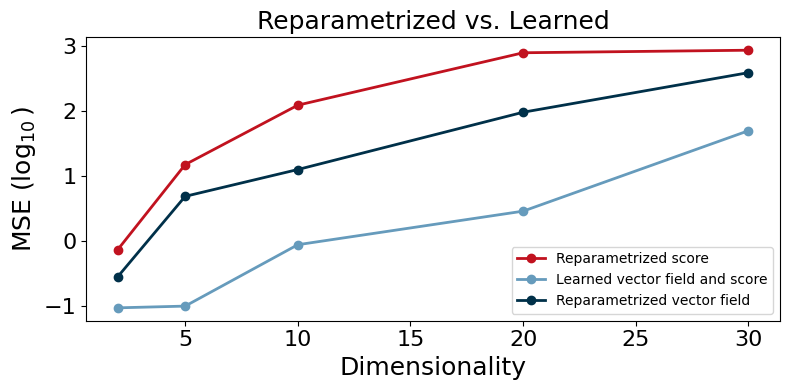

In [67]:
fig = plt.figure(figsize=(8, 4))

colors = {"repar score": "#C1121F", "repar vf": "#003049", "learned": "#669BBC"}
labels = {"repar score": "Reparametrized score", "repar vf": "Reparametrized vector field", "learned": "Learned vector field and score"}

types = df.type.unique()
for t in types:
    plt.plot(
        df[df.type == t]['num_dims'], 
        np.log10(df[df.type == t]['value']), 
        marker='o',
        label=labels[t],
        linewidth=2,
        color=colors[t]
    )

plt.xlabel('Dimensionality', fontsize=18)
plt.ylabel(r'MSE ($\log_{{10}}$)', fontsize=18)
plt.title("Reparametrized vs. Learned", fontsize=18)
plt.grid(visible=False)
plt.tick_params(labelsize=16)
plt.legend()

plt.tight_layout()
plt.savefig("saved_plots/reparametrized.pdf", dpi=300, bbox_inches="tight")
plt.show()